# 02 — First look at vessel movement

**Project:** Maritime Traffic & Environmental Performance Analytics

## Purpose

The cleaning stage established what the AIS fields contain and which values need special handling. This notebook begins descriptive analysis of the cleaned position reports. The first questions are practical: what period and area do the reports cover, how often are positions reported, and what do the recorded speeds and vessel locations look like?

These summaries describe the local extract. They do not yet explain why vessels behave as they do, establish a relationship with weather or waves, or support a prediction model. Environmental matching and any later statistical analysis come after the basic movement patterns are understood.

## How to read the steps

Each section states the question, why it matters, and what the code calculates. The outputs are evidence to discuss, not conclusions on their own. In particular, a high or low AIS value should be interpreted with its message type, units, and cleaning flags in view.

## 1. Load the fields needed for this first pass

The cleaned AIS position file is the starting point because each row represents a vessel position report. Only the columns needed for time coverage, reporting intervals, speed, navigation status, and location are loaded. The cleaned speed field excludes values that represent AIS special codes; the original speed and its flag remain available for checking how that decision affects the summaries.

This file contains close to 19 million rows, so loading even a subset of columns can take time and memory. The code prints the file size and row count first.

In [1]:
# Import the path, table, numeric, and plotting tools used in this notebook.
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Find the project root whether Jupyter starts in the root folder or notebooks folder.
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

# Point to the cleaned AIS position file created in the audit notebook.
AIS_FILE = ROOT / "data" / "processed" / "ais_positions_clean.parquet"

# Stop early with a clear message if the cleaning notebook has not been run.
if not AIS_FILE.exists():
    raise FileNotFoundError(f"Cleaned AIS file not found: {AIS_FILE}")

# List only fields used in the initial movement analysis.
AIS_COLUMNS = [
    "Mmsi", "Date_utc", "Latitude", "Longitude", "SpeedOverGround",
    "sog_knots_clean", "sog_upper_code_flag", "sog_message27_unavailable_flag",
    "NavigationStatus", "MessageType"
]

# Report the source file size before loading millions of rows.
print(f"Cleaned AIS file size: {AIS_FILE.stat().st_size / (1024**2):,.1f} MiB")

# Load the selected fields while leaving the source file unchanged.
ais = pd.read_parquet(AIS_FILE, columns=AIS_COLUMNS)

# Show the row count and in-memory size to make the scale of the analysis clear.
print(f"Rows loaded: {len(ais):,}")
print(f"Approximate dataframe memory: {ais.memory_usage(deep=True).sum() / (1024**3):,.2f} GiB")

# Display the selected field types and a few records to confirm they loaded as expected.
display(ais.dtypes.rename("dtype").to_frame())
display(ais.head())

Saved row-level preview omitted from the public copy to avoid republishing individual source records. Run this cell locally with the source files to inspect the rows.


## 2. Establish the time and geographic coverage

Before reading distributions, it helps to see the span of the extract. The table below reports the first and last position times, the number of distinct vessels, and the latitude and longitude limits. A bounding box only describes the outermost points; it does not mean every location inside it has observations or that all points belong to the English Channel.

,value
position_reports,18973676
distinct_vessels,25130
first_report_utc,2023-06-30 23:58:37+00:00
last_report_utc,2023-09-30 23:58:13+00:00
latitude_min,48.11964
latitude_max,51.385742
longitude_min,-6.928588
longitude_max,2.52362


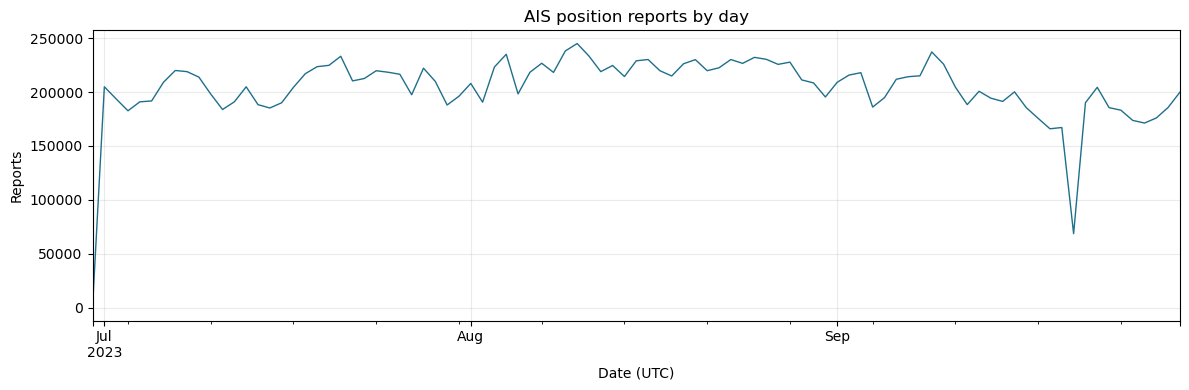

In [2]:
# Summarize the time span, vessel count, and coordinate limits of the cleaned reports.
coverage = pd.DataFrame([{
    "position_reports": len(ais),
    "distinct_vessels": ais["Mmsi"].nunique(),
    "first_report_utc": ais["Date_utc"].min(),
    "last_report_utc": ais["Date_utc"].max(),
    "latitude_min": ais["Latitude"].min(),
    "latitude_max": ais["Latitude"].max(),
    "longitude_min": ais["Longitude"].min(),
    "longitude_max": ais["Longitude"].max(),
}])

# Display coverage values before making any claims about study-area coverage.
display(coverage.T.rename(columns={0: "value"}))

# Count reports by calendar date to reveal whether coverage is balanced through time.
reports_by_day = ais.groupby(ais["Date_utc"].dt.floor("D")).size().rename("reports")

# Plot daily report counts so gaps or unusually busy days are visible.
ax = reports_by_day.plot(figsize=(12, 4), color="#1f6f8b", linewidth=1)
ax.set(title="AIS position reports by day", xlabel="Date (UTC)", ylabel="Reports")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### How to interpret this section

A day with fewer reports could reflect a genuine change in traffic, a change in data collection, or incomplete coverage. The plot alone cannot distinguish these explanations. Note any clear gaps or abrupt changes, then compare them with the source period and other datasets before treating daily counts as traffic volume.

## 3. Examine how frequently positions are reported

AIS does not produce one fixed-rate observation stream for every vessel in this extract. To describe the gaps between reports, the records are ordered by vessel and time; the time difference to the next report for the same vessel is then calculated. Both the full interval distribution and a closer look at gaps up to six hours are shown. Longer gaps remain part of the data and are not discarded; the shorter-gap view simply makes routine reporting intervals easier to see.

,minutes
0.50,12.000000
0.75,14.983333
0.90,24.050000
0.95,45.033333
0.99,330.225833


,share of positive gaps (%)
up to 2 minutes,0.00
over 2 to 10 minutes,21.77
over 10 to 60 minutes,74.64
over 1 to 6 hours,2.60
over 6 hours,0.98


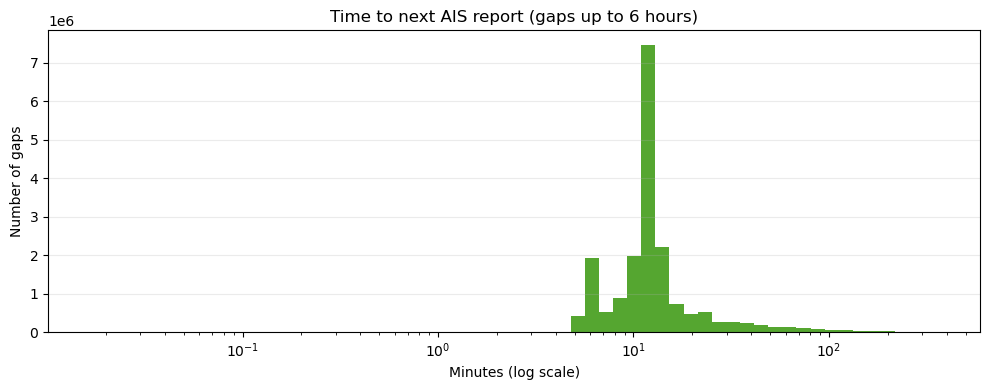

In [3]:
# Sort reports so each vessel's consecutive positions are next to one another.
ais_ordered = ais.sort_values(["Mmsi", "Date_utc"], kind="stable")

# Calculate the time in minutes from each report to the next report for that vessel.
ais_ordered["minutes_to_next_report"] = (
    ais_ordered.groupby("Mmsi", sort=False)["Date_utc"].shift(-1) - ais_ordered["Date_utc"]
).dt.total_seconds().div(60)

# Keep positive intervals; non-positive values would need separate timestamp review.
report_gaps = ais_ordered.loc[
    ais_ordered["minutes_to_next_report"].gt(0), "minutes_to_next_report"
]

# Summarize key percentiles because interval data are usually strongly right-skewed.
gap_summary = report_gaps.quantile([0.50, 0.75, 0.90, 0.95, 0.99]).rename("minutes")
display(gap_summary.to_frame())

# Count the share of report gaps within practical time bands for a readable cadence profile.
gap_bands = pd.Series({
    "up to 2 minutes": report_gaps.le(2).mean() * 100,
    "over 2 to 10 minutes": (report_gaps.gt(2) & report_gaps.le(10)).mean() * 100,
    "over 10 to 60 minutes": (report_gaps.gt(10) & report_gaps.le(60)).mean() * 100,
    "over 1 to 6 hours": (report_gaps.gt(60) & report_gaps.le(360)).mean() * 100,
    "over 6 hours": report_gaps.gt(360).mean() * 100,
}, name="share of positive gaps (%)")
display(gap_bands.to_frame().round(2))

# Keep intervals up to six hours so the routine reporting range is easier to inspect.
short_gaps = report_gaps.loc[report_gaps.le(360)]

# Set histogram bin edges on a log scale so short intervals are not compressed into one wide bin.
log_bins = np.logspace(np.log10(short_gaps.min()), np.log10(short_gaps.max()), 61)

# Draw the interval counts using those log-spaced bins.
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(short_gaps, bins=log_bins, color="#55a630")
ax.set_xscale("log")
ax.set(title="Time to next AIS report (gaps up to 6 hours)", xlabel="Minutes (log scale)", ylabel="Number of gaps")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

### How to interpret this section

A short interval means reports arrived close together; a long interval means the vessel was not observed for longer. Reporting gaps depend on AIS message behaviour, vessel movement, reception, and the study extract. They are not automatically evidence of poor vessel performance or a malfunction. The percentiles and plot help select sensible time windows for later track analysis and environmental matching.

## 4. Look at recorded speed and navigation status

Speed over ground (SOG) is the vessel's speed relative to the Earth's surface. It is not the same as speed through water, because current can make the two differ. The cleaned SOG field is used for the distribution so message-specific unavailable codes are not treated as measured speeds. For Message Type 27, SOG code 63 means unavailable; for the ordinary AIS SOG field, code 102.2 knots or higher is upper-censored. The source values and separate flags remain visible alongside the cleaned field.

Navigation status is reported as a code. Its frequency can help describe the records, but it should not be read as a direct measure of vessel activity without checking the code meanings and how status is populated.

,reports
cleaned speed available,18898520
source SOG missing,53046
AIS upper-limit code flagged,4
Message 27 SOG 63 unavailable,22106


,speed over ground (knots)
count,1.889852e+07
mean,3.081740e+00
std,4.699215e+00
min,0.000000e+00
50%,0.000000e+00
75%,5.400000e+00
90%,1.100000e+01
95%,1.330000e+01
99%,1.830000e+01
max,1.012000e+02


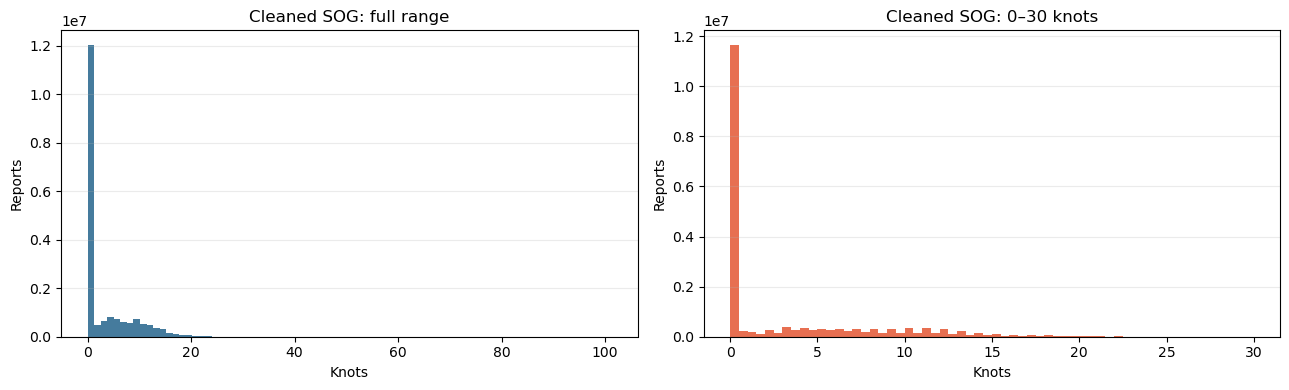

,reports
source code,
NaN,9776299
0.0,4762107
5.0,1941432
7.0,945253
15.0,656918
1.0,454129
3.0,271844
8.0,96168
9.0,16392


,reports
message type,
1,3365437
2,962
3,2021991
18,9773875
19,2424
27,3808987


In [4]:
# Count raw SOG blanks and upper-limit codes before summarizing measured speed values.
sog_quality = pd.Series({
    "cleaned speed available": int(ais["sog_knots_clean"].notna().sum()),
    "source SOG missing": int(ais["SpeedOverGround"].isna().sum()),
    "AIS upper-limit code flagged": int(ais["sog_upper_code_flag"].fillna(False).sum()),
    "Message 27 SOG 63 unavailable": int(ais["sog_message27_unavailable_flag"].fillna(False).sum()),
}, name="reports")
display(sog_quality.to_frame())

# Summarize cleaned SOG with percentiles to show its centre and upper tail.
sog_summary = ais["sog_knots_clean"].describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99])
display(sog_summary.to_frame(name="speed over ground (knots)"))

# Plot a broad speed range first; a second plot focuses on common lower speeds.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ais["sog_knots_clean"].dropna().plot(kind="hist", bins=80, ax=axes[0], color="#457b9d")
axes[0].set(title="Cleaned SOG: full range", xlabel="Knots", ylabel="Reports")
ais.loc[ais["sog_knots_clean"].between(0, 30), "sog_knots_clean"].dropna().plot(
    kind="hist", bins=60, ax=axes[1], color="#e76f51"
)
axes[1].set(title="Cleaned SOG: 0–30 knots", xlabel="Knots", ylabel="Reports")
for axis in axes:
    axis.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# Show the most frequent navigation-status codes without assuming their meaning.
status_counts = ais["NavigationStatus"].value_counts(dropna=False).rename_axis("source code").to_frame("reports")
display(status_counts.head(20))

# Compare report counts by AIS message type to understand the mix of position-report formats.
message_counts = ais["MessageType"].value_counts(dropna=False).sort_index().rename_axis("message type").to_frame("reports")
display(message_counts)

### How to interpret this section

The two speed plots answer different questions: the full range shows the upper tail, while the 0–30 knot view makes the most common lower-speed range easier to inspect. Neither plot alone identifies a vessel as underway, anchored, or manoeuvring. Navigation status and message type provide useful context, but code meanings and missingness should be checked before drawing those conclusions.

## 5. View where the reports are concentrated

A point-density view can show the broad geography of the extract without drawing millions of markers. The plotting sample is taken with a fixed random seed so the same run gives the same picture. The sample is for visual clarity only; the coverage and speed summaries above use the full cleaned dataset.

In [5]:
# Take a reproducible sample of coordinates for the map-style density plot.
map_sample = ais[["Longitude", "Latitude"]].dropna().sample(
    n=min(500_000, ais[["Longitude", "Latitude"]].dropna().shape[0]),
    random_state=42
)

# Plot report density in longitude/latitude space; colour shows the number of sampled reports.
fig, axis = plt.subplots(figsize=(10, 7))
plot = axis.hexbin(
    map_sample["Longitude"], map_sample["Latitude"],
    gridsize=100, mincnt=1, bins="log", cmap="viridis"
)
axis.set(title="AIS position-report density (reproducible sample)",
         xlabel="Longitude (degrees)", ylabel="Latitude (degrees)")
axis.set_aspect("equal", adjustable="box")
fig.colorbar(plot, ax=axis, label="Sampled reports per hexagon (log colour scale)")
axis.grid(alpha=0.15)
plt.tight_layout()
plt.show()

Saved row-level preview omitted from the public copy to avoid republishing individual source records. Run this cell locally with the source files to inspect the rows.


### How to interpret this section

This plot shows where reports are concentrated in the supplied extract, not the number of unique vessels or a shipping-lane boundary. AIS reporting frequency can make a vessel appear as many nearby points. A later analysis can compare locations using vessel counts, time periods, or a defined study-area boundary, depending on the question.

## 6. Record observations before deciding what to analyse next

After running the notebook, summarize the observed coverage, reporting gaps, speed distribution, status-code pattern, and spatial concentration in your own words. Separate what the output directly shows from possible explanations. Any interpretation of navigation codes should be checked against their documented definitions.

### Questions for discussion

- Does the time series suggest complete and steady coverage, or are there gaps that need explanation?
- Which reporting-gap ranges appear common, and how might that affect track comparisons?
- Does the cleaned speed distribution look plausible for the mix of message types and vessels?
- Are the strongest spatial concentrations consistent with the intended study area?
- Which finding should guide the next EDA step: vessel type and characteristics, spatial coverage, or movement over time?

The next step should follow from these observations. Environmental matching is a later stage and requires an explicit spatial and time tolerance, as well as a policy for positions outside the grid coverage.